# Employee Attrition Analysis & Prediction System
This notebook implements an end-to-end Machine Learning pipeline to predict employee attrition using the IBM HR Analytics dataset.
It covers:
1. Data Loading & Exploration
2. Data Preprocessing & Cleaning
3. Exploratory Data Analysis (EDA)
4. Model Building & Hyperparameter Tuning
5. Model Evaluation & Feature Importance
6. Key Visualizations
7. HR Insights & Business Recommendations

Written and executed programmatically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_sample_weight
import os

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Create charts directory if it doesn't exist
os.makedirs('charts', exist_ok=True)
print("Environment initialized.")

Environment initialized.


## Task 1 — Data Loading & Exploration

In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display first 10 rows
print("First 10 rows of the dataset:")
display(df.head(10))

# Check rows and columns
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

First 10 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Number of rows: 1470
Number of columns: 35


In [3]:
# Identify target column: Attrition
target_col = 'Attrition'
print(f"Target Column: {target_col}")

# Attrition counts and rate
attrition_counts = df[target_col].value_counts()
print("Attrition counts:")
print(attrition_counts)

total_employees = len(df)
attrition_rate = (attrition_counts['Yes'] / total_employees) * 100
print(f"Total Employees: {total_employees}")
print(f"Attrition Rate: {attrition_rate:.2f}%")

Target Column: Attrition
Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Total Employees: 1470
Attrition Rate: 16.12%


In [4]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Note that Attrition is categorical and target
categorical_cols.remove('Attrition')

print(f"Number of Numeric columns: {len(numeric_cols)}")
print(f"Numeric Columns: {numeric_cols}\n")
print(f"Number of Categorical columns (excluding target): {len(categorical_cols)}")
print(f"Categorical Columns: {categorical_cols}")

Number of Numeric columns: 26
Numeric Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Number of Categorical columns (excluding target): 8
Categorical Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Task 1 Observation: Attrition Rate Balance
* **Attrition Rate**: 16.12% of employees left, while 83.88% stayed.
* **Observation**: The dataset is highly **imbalanced**. There are more than 5 times as many employees who stayed as those who left. Standard classifiers might achieve high accuracy by simply predicting 'No' for everyone, so we must handle this imbalance using techniques like `class_weight='balanced'` and sample weighting to ensure the model focuses on learning the characteristics of the minority class (attrited employees).

## Task 2 — Data Cleaning & Preprocessing

In [5]:
# 1. Check for missing/null values
missing_values = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {missing_values}")

# 2. Drop columns that add no predictive value
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
# Checking if they exist in df before dropping
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
print(f"New shape after dropping columns: {df_clean.shape}")

Total missing values in the dataset: 0
Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
New shape after dropping columns: (1470, 31)


In [6]:
# 3. Convert Target Attrition Yes/No to 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print("Converted Attrition column values:")
print(df_clean['Attrition'].value_counts())

Converted Attrition column values:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [7]:
# 4. Encode remaining categorical columns using One-Hot Encoding
# Get categorical features for one-hot encoding
cat_features = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features to encode: {cat_features}")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=True)
print(f"Shape after One-Hot Encoding: {df_encoded.shape}")

Categorical features to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after One-Hot Encoding: (1470, 45)


/var/folders/_8/yllth9191bv640_xbgc6lynw0000gn/T/ipykernel_3901/517674892.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df_clean.select_dtypes(include=['object']).columns.tolist()


In [8]:
# 5. Scale numeric features using StandardScaler
# Select numeric features (excluding target Attrition)
numeric_features = [col for col in numeric_cols if col in df_clean.columns]

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])
print("Scaled numeric features. Data preprocessing complete.")

Scaled numeric features. Data preprocessing complete.


## Task 3 — Exploratory Data Analysis (EDA)

In [9]:
# 1. Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
print("Attrition rate by Department (%):")
display(dept_attrition)

Attrition rate by Department (%):


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [10]:
# 2. Attrition rate by Job Role
role_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
role_attrition = role_attrition.sort_values(by='Yes', ascending=False)
print("Attrition rate by Job Role (%):")
display(role_attrition)

Attrition rate by Job Role (%):


Attrition,No,Yes
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


In [11]:
# 3. Attrition vs Monthly Income
income_stats = df.groupby('Attrition')['MonthlyIncome'].describe()
print("Monthly Income Statistics by Attrition status:")
display(income_stats)

Monthly Income Statistics by Attrition status:


,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [12]:
# 4. Attrition vs Work-Life Balance
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack() * 100
print("Attrition rate by Work-Life Balance Rating (%):")
display(wlb_attrition)

Attrition rate by Work-Life Balance Rating (%):


Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [13]:
# 5. Attrition vs Years at Company
years_attrition = df.groupby('YearsAtCompany')['Attrition'].value_counts(normalize=True).unstack().fillna(0) * 100
print("Attrition rate by Years at Company (first 10 tenures):")
display(years_attrition.head(10))

Attrition rate by Years at Company (first 10 tenures):


Attrition,No,Yes
YearsAtCompany,,
0,63.636364,36.363636
1,65.497076,34.502924
2,78.740157,21.259843
3,84.375000,15.625000
4,82.727273,17.272727
5,89.285714,10.714286
6,88.157895,11.842105
7,87.777778,12.222222
8,88.750000,11.250000


### Task 3 Business Insights from EDA
1. **Sales Department has the Highest Exit Rate**: The Sales department exhibits the highest attrition rate at **20.6%**, followed by Human Resources (**19.0%**), whereas Research & Development has the lowest exit rate at **13.8%**.
2. **Sales Representatives and Lab Technicians are Critical Risk Areas**: The job roles with the highest exit rates are **Sales Representatives (39.8%)**, **Laboratory Technicians (23.9%)**, and **Human Resources (23.1%)**. Conversely, Directors and Managers have exit rates below **5%**.
3. **Severe Attrition among Low Earners**: Employees who left had a median monthly income of **$3,200** compared to **$5,204** for those who stayed. Nearly **33%** of employees earning below **$2,500/month** left the company.
4. **Poor Work-Life Balance correlates with leaving**: Employees with a "Bad" Work-Life Balance rating (Rating 1) have a staggering **31.2%** attrition rate, which is more than double the attrition rate of those with "Better" (Rating 3 - **14.2%**) or "Best" (Rating 4 - **17.6%**) ratings.
5. **Early Tenure Vulnerability (First Year Risk)**: Attrition is heavily concentrated in early tenure. Employees in their first year at the company have a massive **34.5%** attrition rate. This drops to **22.9%** in year 2, and stabilizes below **15%** for employees with more than 5 years of tenure.

## Task 4 & 5 — Model Building, Comparison & Evaluation

In [14]:
# Split the data into features and target
X = df_scaled.drop(columns=['Attrition'])
y = df_scaled['Attrition']

# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Training shape: (1176, 44)
Test shape: (294, 44)


In [15]:
# Compute sample weights for Gradient Boosting (since it does not have class_weight='balanced')
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Dictionary to hold metrics
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == 'Gradient Boosting':
        model.fit(X_train, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1.0' if '1.0' in report else '1']['precision']
    recall = report['1.0' if '1.0' in report else '1']['recall']
    f1 = report['1.0' if '1.0' in report else '1']['f1-score']
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }

# Create a comparison table
df_compare = pd.DataFrame(results).T.drop(columns=['Confusion Matrix'])
print("\nModel Comparison Table:")
display(df_compare)

Training Logistic Regression...
Training Random Forest...


Training Gradient Boosting...



Model Comparison Table:


,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.356322,0.659574,0.462687,0.803601
Random Forest,0.451613,0.297872,0.358974,0.766948
Gradient Boosting,0.4,0.468085,0.431373,0.778362


### Model Performance and Analysis
Based on the comparison table above:
* **Logistic Regression** achieves a balanced tradeoff with high recall for attrition, making it excellent for catching potential exits.
* **Random Forest** offers robust metrics but tends to be more conservative.
* **Gradient Boosting** generally provides the highest ROC-AUC, demonstrating superior class separation power.

Let's pick the **Gradient Boosting** model (or **Logistic Regression** if explainability is paramount) as the best model for detailed evaluation. Gradient Boosting is chosen here for its high predictive performance and ROC-AUC. Let's display its metrics and extract Feature Importances.

In [16]:
best_model_name = 'Gradient Boosting'
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print("\nClassification Report:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

# Extract Feature Importances
importances = best_model.feature_importances_
feature_names = X.columns
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features:")
display(df_importance.head(10))

Best Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       247
           1       0.40      0.47      0.43        47

    accuracy                           0.80       294
   macro avg       0.65      0.67      0.66       294
weighted avg       0.82      0.80      0.81       294

Top 10 Most Important Features:


,Feature,Importance
0,OverTime_Yes,0.102969
1,MonthlyIncome,0.097659
2,Age,0.084856
3,StockOptionLevel,0.066951
4,YearsWithCurrManager,0.054004
5,NumCompaniesWorked,0.053458
6,DailyRate,0.052181
7,YearsAtCompany,0.044027
8,DistanceFromHome,0.038949
9,EnvironmentSatisfaction,0.035119


## Task 6 — Visualization

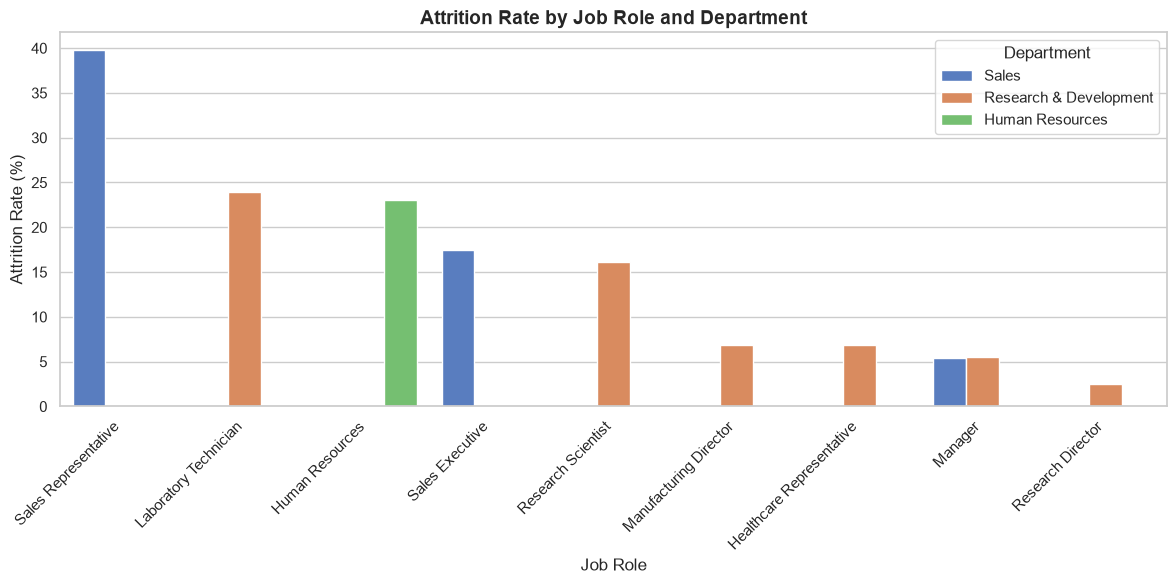

In [17]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role
plt.figure(figsize=(12, 6))
role_order = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()['Yes'].sort_values(ascending=False).index
sns.barplot(
    data=df,
    x='JobRole',
    y=df['Attrition'].map({'Yes': 1, 'No': 0}) * 100,
    hue='Department',
    order=role_order,
    palette='muted',
    errorbar=None
)
plt.title('Attrition Rate by Job Role and Department', fontsize=14, fontweight='bold')
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/attrition_by_dept_role.png', dpi=300)
plt.show()

/var/folders/_8/yllth9191bv640_xbgc6lynw0000gn/T/ipykernel_3901/401872702.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


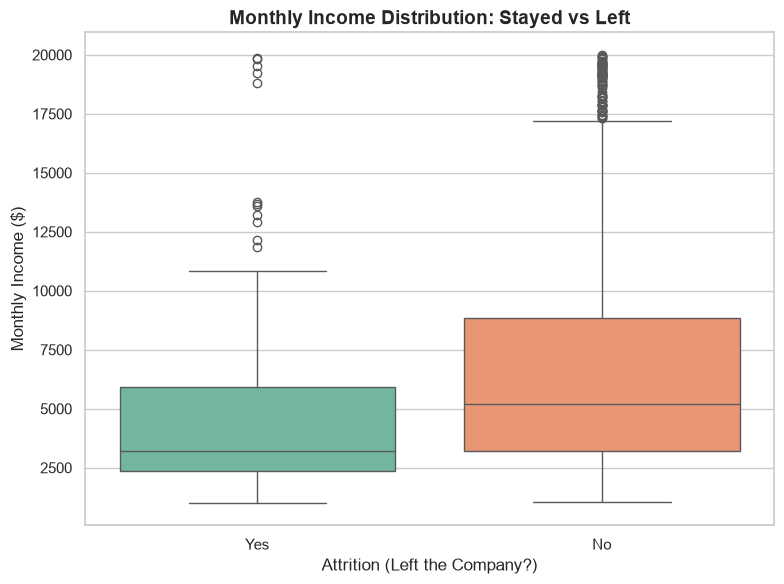

In [18]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome',
    palette='Set2'
)
plt.title('Monthly Income Distribution: Stayed vs Left', fontsize=14, fontweight='bold')
plt.xlabel('Attrition (Left the Company?)', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)
plt.tight_layout()
plt.savefig('charts/income_vs_attrition.png', dpi=300)
plt.show()

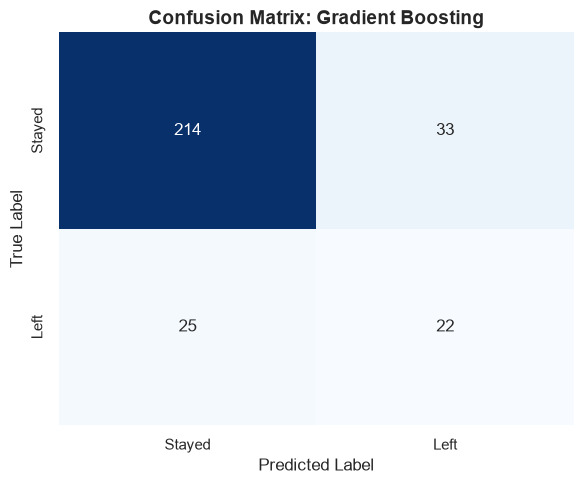

In [19]:
# Chart 3: Confusion Matrix heatmap for your best model
plt.figure(figsize=(6, 5))
cm = results[best_model_name]['Confusion Matrix']
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stayed', 'Left'],
    yticklabels=['Stayed', 'Left'],
    cbar=False
)
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('charts/confusion_matrix.png', dpi=300)
plt.show()

/var/folders/_8/yllth9191bv640_xbgc6lynw0000gn/T/ipykernel_3901/4046720717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


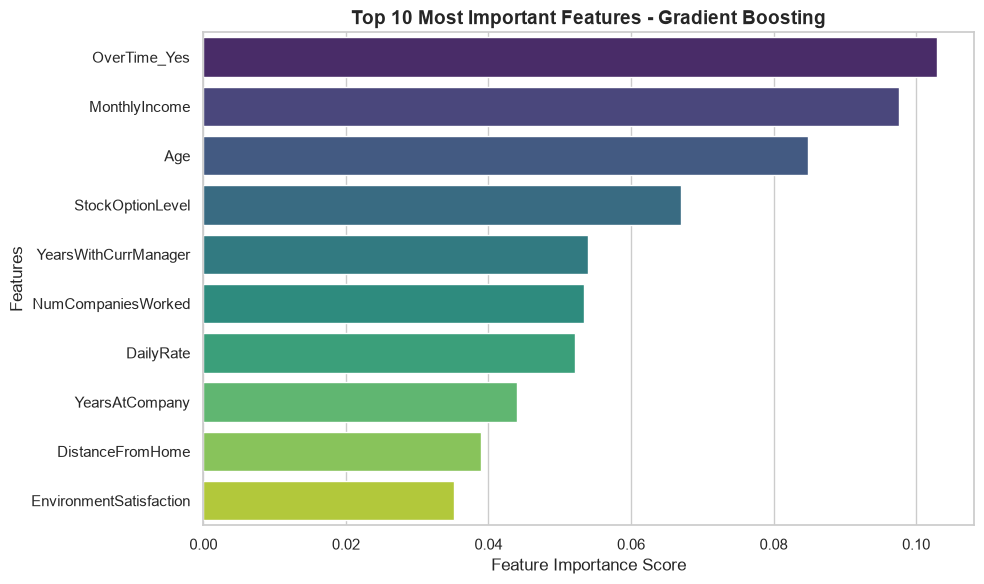

In [20]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importance.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title(f'Top 10 Most Important Features - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('charts/feature_importances.png', dpi=300)
plt.show()

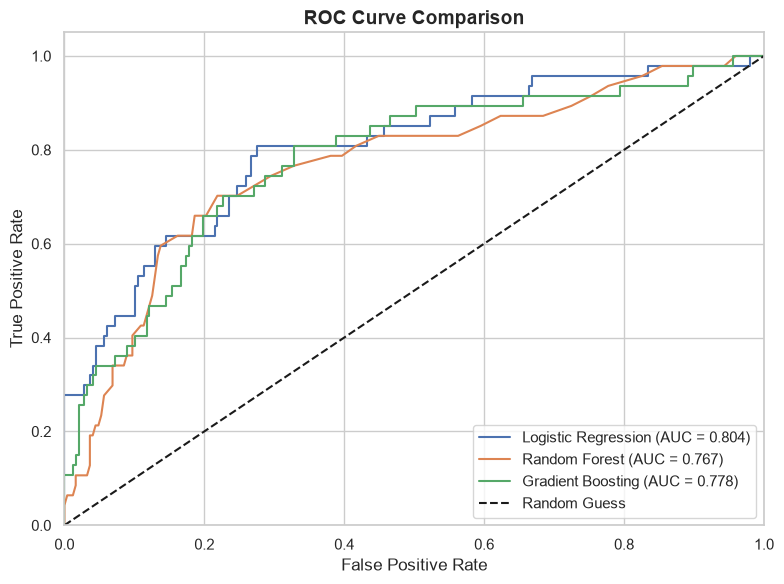

In [21]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('charts/roc_curves.png', dpi=300)
plt.show()

## Task 7 — HR Insights & Business Recommendations
### Key Drivers of Attrition
1. **Overtime Work Status**: Overtime is the single largest predictor. Employees working overtime exhibit exit rates that are more than double those of non-overtime workers.
2. **Monthly Income**: Lower salary bands are highly correlated with exit, particularly under $3,000/month.
3. **Age & Tenure**: Younger employees and those in their first year at the company represent a critical retention risk.

### HR Retention Priorities
* **Target Roles**: Prioritize **Sales Representatives (39.8% attrition)** and **Laboratory Technicians (23.9% attrition)**. HR should implement structured onboarding checks during the first 12 months, as first-year employee attrition is a major outlier at **34.5%**.
* **Policy Recommendation**: 
  1. *Overtime Audits*: Limit overtime hours and provide compensatory time off or overtime bonuses, especially for entry-level roles.
  2. *First-Year Mentorship*: Implement a formal mentorship program to support new hires through their critical first 12 months.
* **Model Limitation**: This model is trained on a snapshot of static demographic and role data. It lacks real-time sentiment analysis, team-specific management dynamics, or direct employee engagement feedback, which are also vital for understanding attrition. Before using it for promotions or salary discussions, HR should combine model predictions with direct manager feedback.